# Lee-Carter mortality projections on official Eurostat data

This notebook estimates and validates a stochastic mortality model for ages 50-99 from **official Eurostat statistics**
(deaths by single age, dataset `demo_magec`, and population on 1 January, dataset `demo_pjan`), separately for men and women.

1. Central exposures and crude death rates.
2. Poisson log-bilinear Lee-Carter fit (Brouhns, Denuit and Vermunt, 2002), compared with the original SVD fit (Lee and Carter, 1992).
3. Goodness of fit: deviance residuals and cohort effects.
4. Random walk with drift for the period index $k_t$, with and without the pandemic years.
5. Out-of-sample backtest of the forecast intervals of period life expectancy at 65.
6. Stochastic projections with the C++ engine: period versus cohort life expectancy.

**Model.** $D_{x,t} \sim \text{Poisson}(E_{x,t}\, m_{x,t})$ with $\ln m_{x,t} = a_x + b_x k_t$, $\sum_x b_x = 1$, $\sum_t k_t = 0$;
$k_t = k_{t-1} + d + \sigma \varepsilon_t$ with $\varepsilon_t$ i.i.d. standard normal.

**Conventions.** Ages are ages last birthday, years are calendar years, $E_{x,t}$ is the central exposure approximated by the
average of the populations on 1 January of $t$ and $t+1$; the force of mortality is constant within each year of age, so $q = 1 - e^{-m}$.
The pandemic years 2020-2022 receive zero weight in the fit (a modelling choice discussed in section 4).

**Requirements.** Build the extension with `python -m pip install -e scripts/longevity_risk` (see the project README).
**Data.** `DATA_MODE = "official"` downloads the Eurostat tables into `data/raw/eurostat/`. Set the environment variable
`LONGEVITY_RISK_DATA_MODE=synthetic` to run offline on data simulated from a known Lee-Carter model (not official statistics).

In [1]:
import os
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Repository root (used for data and output paths).
ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "scripts" / "longevity_risk").is_dir())
try:
    import longevity_risk
except ImportError:  # not installed: use the source folder (the extension must be built in place)
    sys.path.insert(0, str(ROOT / "scripts" / "longevity_risk"))
    import longevity_risk
from longevity_risk import data, lee_carter as lc, life_table as lt, simulation as sim, synthetic

core = longevity_risk.require_cpp()

DATA_MODE = os.environ.get("LONGEVITY_RISK_DATA_MODE", "official")  # "official" (Eurostat) or "synthetic"
COUNTRY = "IT"                     # Eurostat country code (IT, DE, FR, ES, ...)
AGES = range(50, 100)              # single ages 50-99 (last birthday)
FIRST_YEAR = 1975                  # first calendar year used (subject to data availability)
PANDEMIC_YEARS = (2020, 2021, 2022)  # given zero weight in the fit
BACKTEST_SPLIT = 2009              # out-of-sample test: fit up to this year, forecast the next ten
N_SCENARIOS = 10_000
SEED = 20240101
OUTPUT_DIR = ROOT / "outputs" / "lee_carter"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
print(f"longevity_risk {longevity_risk.__version__} | data mode: {DATA_MODE} | country: {COUNTRY}")

longevity_risk 0.1.0 | data mode: official | country: IT


## 1. Deaths, exposures and crude death rates

Source: Eurostat demo_magec and demo_pjan, geo=IT, sex=M
Years 1992-2024 (33), ages 50-99; deaths in the sample: men 9,135,893, women 9,609,122


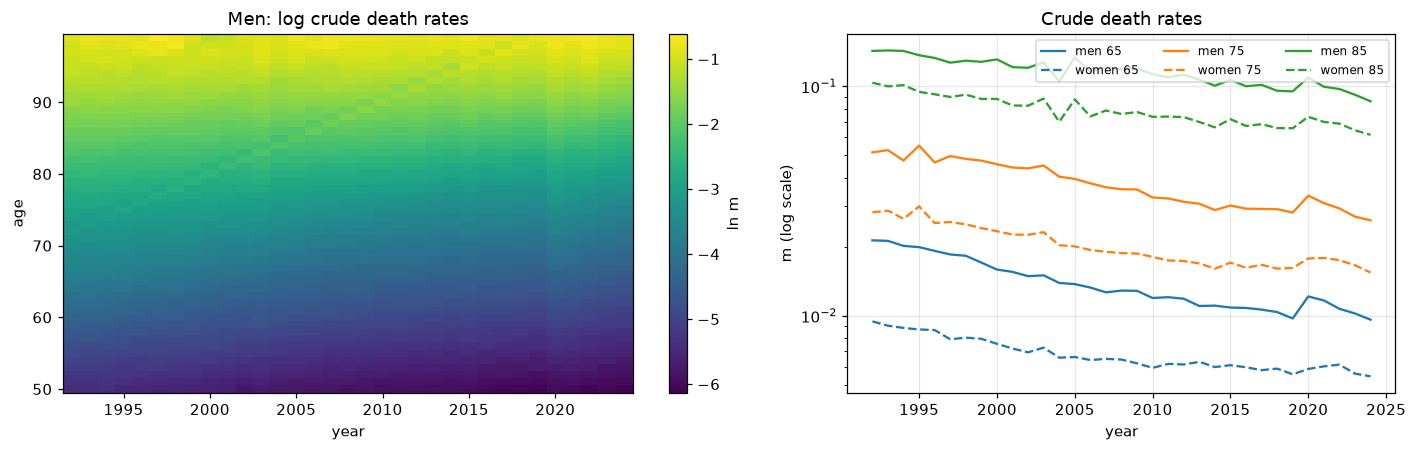

In [2]:
D, E = {}, {}
for sex in ("M", "F"):
    if DATA_MODE == "official":
        D[sex], E[sex] = data.load_deaths_exposures(COUNTRY, sex, AGES)
    else:
        D[sex], E[sex], _ = synthetic.deaths_and_exposures(AGES, range(1975, 2024), seed=7 if sex == "M" else 8,
                                                           drift=-1.2 if sex == "M" else -1.0,
                                                           log_level=0.0 if sex == "M" else -0.4)
    keep = [y for y in D[sex].columns if y >= FIRST_YEAR]
    D[sex], E[sex] = D[sex].loc[:, keep], E[sex].loc[:, keep]
years = D["M"].columns.to_numpy()
print("Source:", D["M"].attrs.get("source"))
print(f"Years {years.min()}-{years.max()} ({years.size}), ages {min(AGES)}-{max(AGES)}; "
      f"deaths in the sample: men {D['M'].to_numpy().sum():,.0f}, women {D['F'].to_numpy().sum():,.0f}")

crude = {sex: np.log(D[sex] / E[sex]) for sex in D}
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), gridspec_kw={"width_ratios": [1.3, 1]})
im = axes[0].imshow(crude["M"].to_numpy(), aspect="auto", origin="lower", cmap="viridis",
                    extent=[years.min() - 0.5, years.max() + 0.5, min(AGES) - 0.5, max(AGES) + 0.5])
fig.colorbar(im, ax=axes[0], label="ln m")
axes[0].set(title="Men: log crude death rates", xlabel="year", ylabel="age")
axes[0].grid(False)
for age, color in zip((65, 75, 85), ("C0", "C1", "C2")):
    axes[1].semilogy(years, (D["M"] / E["M"]).loc[age], color=color, label=f"men {age}")
    axes[1].semilogy(years, (D["F"] / E["F"]).loc[age], color=color, ls="--", label=f"women {age}")
axes[1].set(title="Crude death rates", xlabel="year", ylabel="m (log scale)")
axes[1].legend(ncol=3, fontsize=8)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "crude_rates.png", dpi=150)

## 2. Lee-Carter fit

The Poisson fit maximises $\sum_{x,t} w_t\,[D_{x,t}\ln \hat D_{x,t} - \hat D_{x,t}]$ with Newton updates of $a_x$, $k_t$ and $b_x$ in turn;
the weights $w_t$ are zero in the pandemic years. The SVD fit is the ordinary least-squares solution on $\ln(D/E)$.

M: 14 iterations in 0.01 s, deviance 11,869 on 1,372 degrees of freedom (ratio 8.65)
F: 13 iterations in 0.01 s, deviance 9,586 on 1,372 degrees of freedom (ratio 6.99)


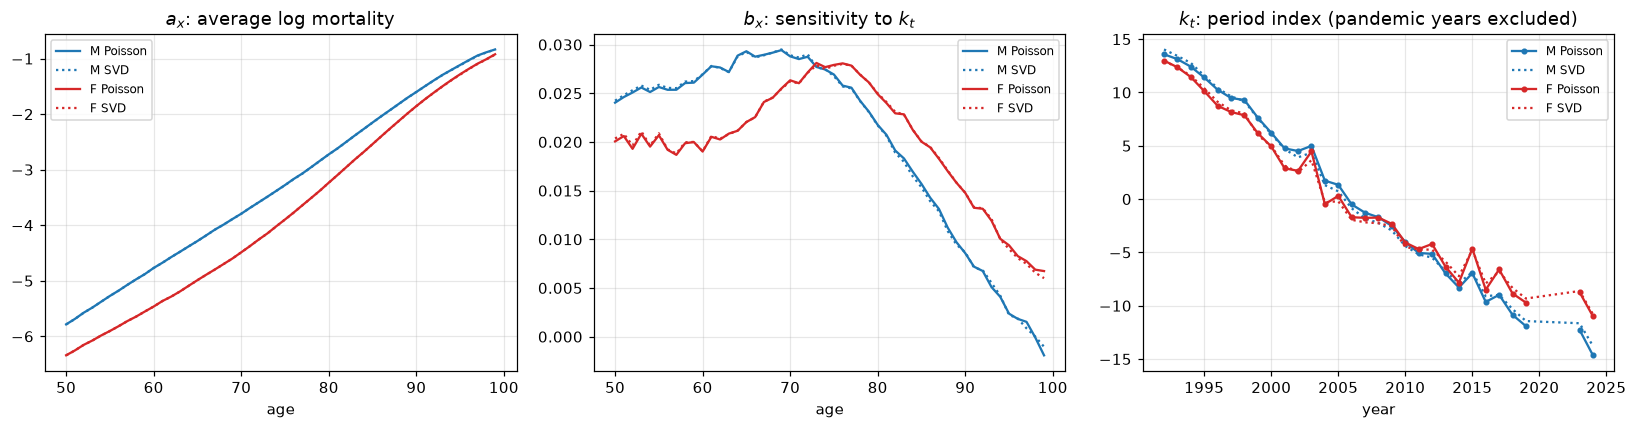

In [3]:
fit_years = [y for y in years if y not in PANDEMIC_YEARS]
fits, svd_fits = {}, {}
for sex in ("M", "F"):
    t0 = time.perf_counter()
    fits[sex] = lc.fit_poisson(D[sex], E[sex], fit_years=fit_years)
    svd_fits[sex] = lc.fit_svd(crude[sex].loc[:, fit_years])
    n_cells = D[sex].shape[0] * len(fit_years)
    dof = n_cells - (2 * D[sex].shape[0] + len(fit_years) - 2)
    print(f"{sex}: {fits[sex].iterations} iterations in {time.perf_counter() - t0:.2f} s, "
          f"deviance {fits[sex].deviance:,.0f} on {dof:,} degrees of freedom (ratio {fits[sex].deviance / dof:.2f})")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for sex, color in (("M", "C0"), ("F", "C3")):
    f, s = fits[sex], svd_fits[sex]
    axes[0].plot(f.ages, f.ax, color=color, label=f"{sex} Poisson")
    axes[0].plot(s.ages, s.ax, color=color, ls=":", label=f"{sex} SVD")
    axes[1].plot(f.ages, f.bx, color=color, label=f"{sex} Poisson")
    axes[1].plot(s.ages, s.bx, color=color, ls=":", label=f"{sex} SVD")
    axes[2].plot(f.years, f.kt, "o-", ms=3, color=color, label=f"{sex} Poisson")
    axes[2].plot(s.years, s.kt, ":", color=color, label=f"{sex} SVD")
axes[0].set(title="$a_x$: average log mortality", xlabel="age")
axes[1].set(title="$b_x$: sensitivity to $k_t$", xlabel="age")
axes[2].set(title="$k_t$: period index (pandemic years excluded)", xlabel="year")
for ax in axes:
    ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "lee_carter_parameters.png", dpi=150)

## 3. Deviance residuals

Under a correct model the deviance residuals are approximately standard normal and without structure. Diagonal bands
(constant year of birth $t - x$) reveal **cohort effects**, which Lee-Carter does not capture; this is its best-known limitation
and motivates extensions such as Renshaw-Haberman or Cairns-Blake-Dowd models.

M: residual mean -0.033, standard deviation 2.813
F: residual mean -0.041, standard deviation 2.528


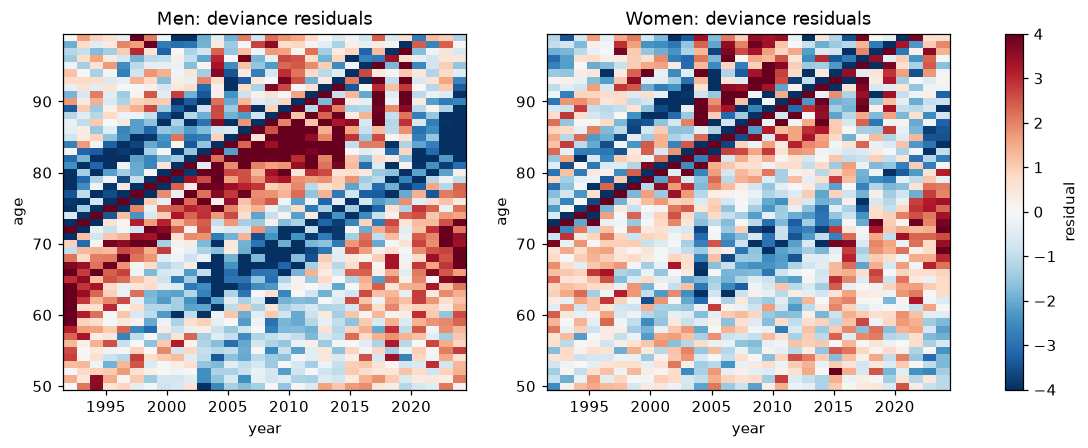

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
for ax, sex in zip(axes, ("M", "F")):
    res = lc.poisson_deviance_residuals(D[sex].loc[:, fit_years], E[sex].loc[:, fit_years],
                                        lc.LeeCarterFit(fits[sex].ages, np.array(fit_years), fits[sex].ax, fits[sex].bx,
                                                        fits[sex].kt[np.isin(years, fit_years)], "poisson"))
    im = ax.imshow(res.to_numpy(), aspect="auto", origin="lower", cmap="RdBu_r", vmin=-4, vmax=4,
                   extent=[min(fit_years) - 0.5, max(fit_years) + 0.5, min(AGES) - 0.5, max(AGES) + 0.5])
    ax.set(title=f"{'Men' if sex == 'M' else 'Women'}: deviance residuals", xlabel="year", ylabel="age")
    ax.grid(False)
    print(f"{sex}: residual mean {res.to_numpy().mean():+.3f}, standard deviation {res.to_numpy().std():.3f}")
fig.colorbar(im, ax=axes, label="residual")
fig.savefig(OUTPUT_DIR / "residuals.png", dpi=150)

## 4. Random walk with drift for $k_t$

$d$ is estimated by $(k_T - k_{t_0})/(T - t_0)$ and $\sigma$ by the variance of the increments (increments across excluded years
count as several annual steps). The standard error of $d$ measures parameter uncertainty and is propagated in the simulations.
The table compares the fit without the pandemic years (main specification) with a fit on all years.

In [5]:
rows = {}
for sex in ("M", "F"):
    for label, fy in (("excluding 2020-22", fit_years), ("all years", list(years))):
        f = fits[sex] if fy is fit_years else lc.fit_poisson(D[sex], E[sex])
        rw = lc.RandomWalkDrift.from_kt(f.years, f.kt)
        rows[(sex, label)] = {"drift d": rw.drift, "sigma": rw.sigma, "s.e.(d)": rw.drift_se,
                              "annual improvement at 65 (%)": 100 * (1 - np.exp(f.bx[65 - min(AGES)] * rw.drift)),
                              "first year": rw.first_year, "last year": rw.last_year}
rw_table = pd.DataFrame(rows).T.astype({"first year": int, "last year": int})
display(rw_table)
for sex in ("M", "F"):
    main, full = rw_table.loc[(sex, "excluding 2020-22")], rw_table.loc[(sex, "all years")]
    print(f"{sex}: including 2020-22 changes sigma by {100 * (full['sigma'] / main['sigma'] - 1):+.1f}% "
          f"and the drift by {100 * (full['drift d'] / main['drift d'] - 1):+.1f}%")

drift d  sigma  s.e.(d)  annual improvement at 65 (%)  \
M excluding 2020-22  -0.8823 1.0354   0.1830                        2.5534   
  all years          -0.8781 1.8189   0.3215                        2.5312   
F excluding 2020-22  -0.7494 1.6819   0.2973                        1.6384   
  all years          -0.7517 2.1155   0.3740                        1.6484   

                     first year  last year  
M excluding 2020-22        1992       2024  
  all years                1992       2024  
F excluding 2020-22        1992       2024  
  all years                1992       2024

M: including 2020-22 changes sigma by +75.7% and the drift by -0.5%
F: including 2020-22 changes sigma by +25.8% and the drift by +0.3%


## 5. Out-of-sample backtest

We refit the model on the years up to `BACKTEST_SPLIT`, simulate 10,000 paths of $k_t$ with the C++ engine (including drift uncertainty),
and compare the 95% forecast interval of period life expectancy at 65 with the observed values of the following ten years
(pandemic years excluded). Period life expectancy uses ages 65-99 with the last age closed as an open group, both for the
observed crude rates and for the projections.

,test years,inside 95% interval,mean error of median (years)
M,10,10,-0.1138
F,10,10,0.0982


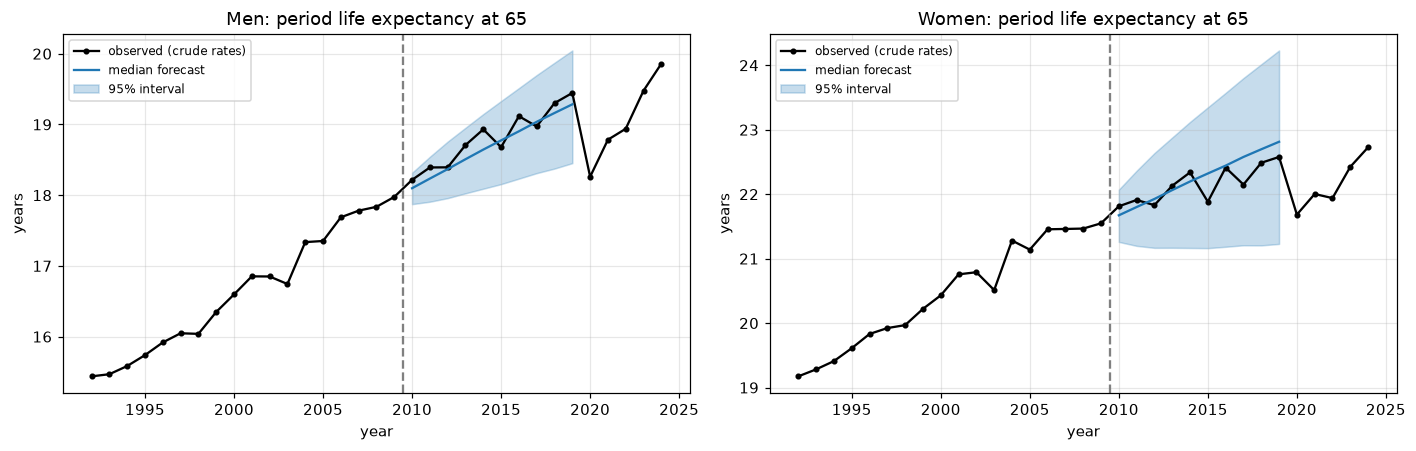

In [6]:
def e65(rates):
    """Period life expectancy at 65 from rates for ages 65..99 (last age open)."""
    return lt.period_life_expectancy(rates)

i65 = 65 - min(AGES)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
coverage = {}
for ax, sex in zip(axes, ("M", "F")):
    train = [y for y in years if y <= BACKTEST_SPLIT]
    test = [y for y in years if BACKTEST_SPLIT < y <= BACKTEST_SPLIT + 10 and y not in PANDEMIC_YEARS]
    model_bt = sim.ProjectionModel.from_fit(lc.fit_poisson(D[sex].loc[:, train], E[sex].loc[:, train]))
    H = model_bt.horizon(65)
    paths = sim.simulate_annuity(model_bt, 65, np.ones(H), N_SCENARIOS, seed=SEED, keep_paths=True)["k_paths"]
    ax_65, bx_65 = model_bt.ax[i65:i65 + 35], model_bt.bx[i65:i65 + 35]
    horizon_years = np.arange(BACKTEST_SPLIT + 1, BACKTEST_SPLIT + 11)
    sims = np.array([e65(np.exp(ax_65[None, :] + bx_65[None, :] * paths[:, h - 1][:, None])) for h in range(1, 11)])
    lo, med, hi = np.percentile(sims, [2.5, 50, 97.5], axis=1)
    observed_all = pd.Series({y: e65((D[sex] / E[sex]).loc[65:99, y].to_numpy()) for y in years})
    inside = [lo[y - BACKTEST_SPLIT - 1] <= observed_all[y] <= hi[y - BACKTEST_SPLIT - 1] for y in test]
    coverage[sex] = {"test years": len(test), "inside 95% interval": int(np.sum(inside)),
                     "mean error of median (years)": float(np.mean([med[y - BACKTEST_SPLIT - 1] - observed_all[y] for y in test]))}
    ax.plot(observed_all.index, observed_all.to_numpy(), "k.-", label="observed (crude rates)")
    ax.plot(horizon_years, med, color="C0", label="median forecast")
    ax.fill_between(horizon_years, lo, hi, color="C0", alpha=0.25, label="95% interval")
    ax.axvline(BACKTEST_SPLIT + 0.5, color="gray", ls="--")
    ax.set(title=f"{'Men' if sex == 'M' else 'Women'}: period life expectancy at 65", xlabel="year", ylabel="years")
    ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "backtest_e65.png", dpi=150)
display(pd.DataFrame(coverage).T.astype({"test years": int, "inside 95% interval": int}))

## 6. Stochastic projections: period versus cohort life expectancy

The **period** life expectancy at 65 uses the death rates of a single calendar year. The **cohort** life expectancy follows a person
aged 65 at the valuation date through the projected rates of the following years (and older ages up to 120, extrapolated with a
Gompertz law for $a_x$ and constant $b_x$). The C++ engine simulates 10,000 scenarios in parallel; we report the curtate cohort
life expectancy $e_{65} = \sum_{t \ge 1} {}_tp_{65}$ plus one half year as an approximation of the complete expectation.

,valuation year T,period e65 (year T),cohort e65 median,cohort e65 5%,cohort e65 95%,cohort e65 99.5%,simulation seconds
M,2024,19.8239,21.3661,20.4725,22.1963,22.6424,0.0172
F,2024,22.7773,24.4337,22.6712,26.1291,27.0364,0.0242


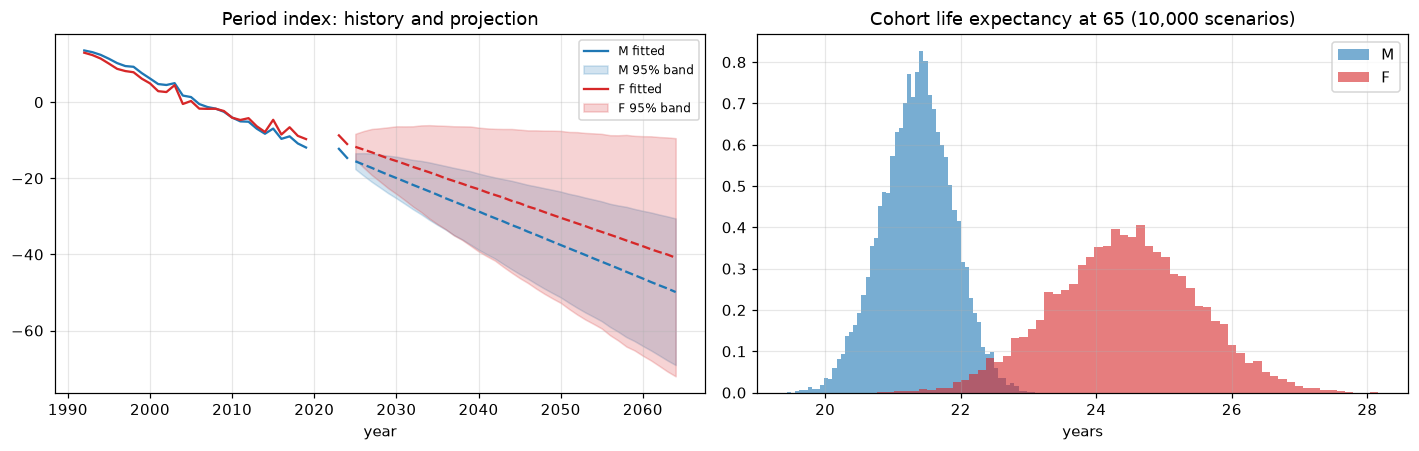

In [7]:
rows = {}
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
for sex, color in (("M", "C0"), ("F", "C3")):
    model = sim.ProjectionModel.from_fit(fits[sex])
    T = model.valuation_year
    H = model.horizon(65)
    t0 = time.perf_counter()
    out = sim.simulate_annuity(model, 65, np.ones(H), N_SCENARIOS, seed=SEED, keep_paths=True)
    elapsed = time.perf_counter() - t0
    cohort = out["life_expectancy"] + 0.5
    period = e65(np.exp(model.ax[i65:i65 + 35] + model.bx[i65:i65 + 35] * model.rw.k_last))
    q = np.percentile(cohort, [0.5, 5, 50, 95, 99.5])
    rows[sex] = {"valuation year T": T, "period e65 (year T)": period, "cohort e65 median": q[2],
                 "cohort e65 5%": q[1], "cohort e65 95%": q[3], "cohort e65 99.5%": q[4], "simulation seconds": elapsed}
    k = out["k_paths"]
    horizon = np.arange(T + 1, T + 1 + H)
    band = np.percentile(k, [2.5, 50, 97.5], axis=0)
    axes[0].plot(fits[sex].years, fits[sex].kt, color=color, label=f"{sex} fitted")
    axes[0].plot(horizon[:40], band[1, :40], color=color, ls="--")
    axes[0].fill_between(horizon[:40], band[0, :40], band[2, :40], color=color, alpha=0.2, label=f"{sex} 95% band")
    axes[1].hist(cohort, bins=60, color=color, alpha=0.6, density=True, label=f"{sex}")
axes[0].set(title="Period index: history and projection", xlabel="year")
axes[0].legend(fontsize=8)
axes[1].set(title="Cohort life expectancy at 65 (10,000 scenarios)", xlabel="years")
axes[1].legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "projections.png", dpi=150)
display(pd.DataFrame(rows).T.astype({"valuation year T": int}))

## 7. Interpretation guide

- $b_x$ usually decreases with age: mortality improvements have been fastest at younger pension ages.
- A deviance-to-degrees-of-freedom ratio well above 1 and diagonal patterns in the residuals indicate over-dispersion and cohort
  effects that a single period index cannot capture.
- Excluding the pandemic years keeps the excess deaths of 2020-2022 from being treated as ordinary random-walk innovations:
  including them mainly increases $\sigma$. The drift estimate depends only on the first and last fitted years, so it changes
  materially only when the series ends in a pandemic year.
- In the backtest, a well-calibrated model should contain most observed values in its 95% interval; systematic misses in one
  direction reveal a change in the pace of improvement not predicted by the drift.
- Cohort life expectancy exceeds period life expectancy whenever mortality keeps improving: pricing annuities with a period
  table understates their cost (see the notebook `notebooks/longevity_risk/annuity_longevity_risk_solvency.ipynb`).

Figures are saved in `outputs/lee_carter/`.

### References

- Brouhns, N., Denuit, M. and Vermunt, J. K. (2002). A Poisson log-bilinear regression approach to the construction of projected lifetables. *Insurance: Mathematics and Economics*, 31(3), 373-393.
- Cairns, A. J. G., Blake, D. and Dowd, K. (2006). A two-factor model for stochastic mortality with parameter uncertainty. *Journal of Risk and Insurance*, 73(4), 687-718.
- Eurostat. Deaths by age and sex (`demo_magec`); Population on 1 January by age and sex (`demo_pjan`). https://ec.europa.eu/eurostat/data/database
- Lee, R. D. and Carter, L. R. (1992). Modeling and forecasting U.S. mortality. *Journal of the American Statistical Association*, 87(419), 659-671.
- Renshaw, A. E. and Haberman, S. (2006). A cohort-based extension to the Lee-Carter model for mortality reduction factors. *Insurance: Mathematics and Economics*, 38(3), 556-570.